# Requirement 4 - improved version

Same instance, environment, and seeds as the baseline. Only the algorithms change, in three ways:

1. **wider window**: SW-UCB uses the global window over rounds from the lab, but with W = L/2 (half the segment length) rather than the worst-case 2*sqrt(T logT/Upsilon_T). With Upsilon_T = 2 and long segments, this remains stationary within the window and provides more samples to each arm in the combinatorial setting.
2. **empirical cost instead of the LCB in the LP**: the cost LCB causes expenditure to happen too quickly.
3. **dynamic pacing**: the LP cap is rho_t = remaining budget / remaining rounds.

CUSUM retains the course formulas (M, h, alpha). The primal-dual method is the improved version from Requirement 3 (theoretical learning rates and per-action budget control), so each method enters the comparison in its best version.

## Setup

Identical to the baseline version: 30 paired trials, three equal segments, with Upsilon_T = 2 known.

In [1]:
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, stats

SEED = 23
T = 3000
TRIALS = 30
BUDGET = 560.0
RHO = BUDGET / T

# instance: non-uniform grid (denser at low bids) and values different from Requirement 2,
# to obtain segments with different attractive campaigns; the problem structure is the same
BID_GRID = np.array([0.0, 0.10, 0.20, 0.30, 0.40, 0.55, 0.70, 0.85])
VALUES = np.array([0.95, 0.88, 0.78, 0.92])
N_CAMPAIGNS = len(VALUES)
N_BIDS = len(BID_GRID)
CONFLICT_EDGES = [(0, 1), (1, 2), (2, 3)]

# Beta(alpha, beta) parameters of the maximum competing bid, per campaign and segment
SEGMENTS = [
    [(2.0, 5.0), (3.2, 3.8), (4.1, 3.0), (2.4, 4.2)],
    [(4.8, 2.3), (2.3, 5.4), (5.0, 2.6), (3.5, 3.0)],
    [(2.4, 2.3), (5.1, 2.0), (2.2, 5.1), (4.4, 2.8)],
]
SEGMENT_LENGTHS = [T // 3, T // 3, T - 2 * (T // 3)]
CHANGE_POINTS = np.cumsum(SEGMENT_LENGTHS)[:-1]

# hyperparameters from the course formulas, with Upsilon_T known by construction
UPSILON_T = len(SEGMENTS) - 1
SEGMENT_LEN = T // (UPSILON_T + 1)                        # 1000: lunghezza di un segmento
SW_WINDOW = int(2 * np.sqrt(T * np.log(T) / UPSILON_T))  # 219: finestra worst-case del corso (per l'ablation)
SW_WINDOW_WIDE = SEGMENT_LEN // 2                         # 500: improved SW window
CUSUM_ALPHA = float(np.sqrt(UPSILON_T * np.log(T / UPSILON_T) / T))
CUSUM_M = int(np.log(T / UPSILON_T))
CUSUM_H = float(2 * np.log(T / UPSILON_T))

BASE_ENV_SEED = 1000

print(f'Upsilon_T = {UPSILON_T}, W = {SW_WINDOW}, alpha = {CUSUM_ALPHA:.4f}, M = {CUSUM_M}, h = {CUSUM_H:.2f}, rho = {RHO:.4f}')

Upsilon_T = 2, W = 219, alpha = 0.0698, M = 7, h = 14.63, rho = 0.1867


## Piecewise-stationary environment

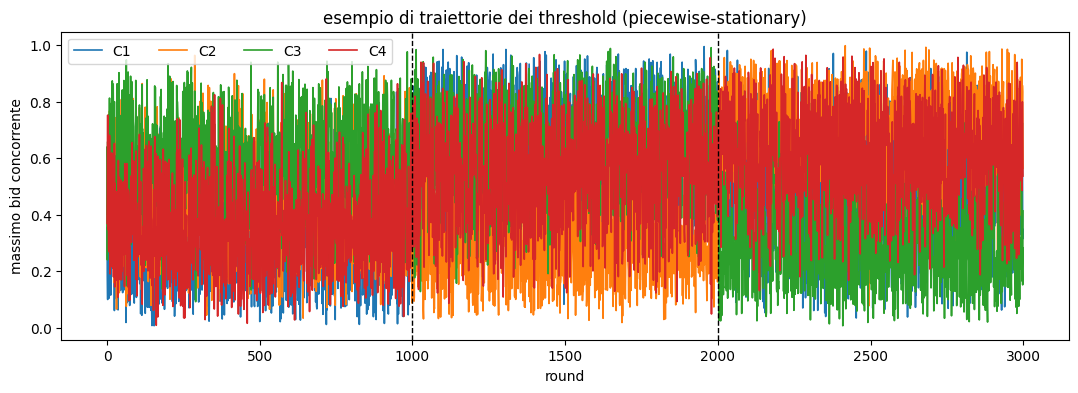

In [2]:
class PiecewiseStationaryEnv:
    # one first-price auction per campaign per round; the threshold distribution
    # changes at change points
    def __init__(self, seed):
        self.rng = np.random.default_rng(seed)
        self.breakpoints = np.cumsum(SEGMENT_LENGTHS)
        self.t = 0

    def draw_thresholds(self):
        segment = SEGMENTS[int(np.searchsorted(self.breakpoints, self.t, side='right'))]
        return np.array([self.rng.beta(a, b) for a, b in segment])

    def round(self, bids):
        thresholds = self.draw_thresholds()
        wins = (bids >= thresholds).astype(float)
        utilities = (VALUES - bids) * wins
        costs = bids * wins
        self.t += 1
        return thresholds, utilities, costs


env = PiecewiseStationaryEnv(seed=SEED)
example_path = np.array([env.round(np.zeros(N_CAMPAIGNS))[0] for _ in range(T)])

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(example_path, linewidth=1.2, label=[f'C{i+1}' for i in range(N_CAMPAIGNS)])
for cp in CHANGE_POINTS:
    ax.axvline(cp, color='black', linestyle='--', linewidth=1)
ax.set_title('esempio di traiettorie dei threshold (piecewise-stationary)')
ax.set_xlabel('round')
ax.set_ylabel('maximum competing bid')
ax.legend(ncol=4)
plt.show()

## Super-actions and budgeted LP

In [3]:
superaction_bid_indices = np.array([
    idxs for idxs in itertools.product(range(N_BIDS), repeat=N_CAMPAIGNS)
    if all(BID_GRID[idxs[i]] == 0 or BID_GRID[idxs[i]] <= VALUES[i] for i in range(N_CAMPAIGNS))
    and all(not (BID_GRID[idxs[i]] > 0 and BID_GRID[idxs[j]] > 0) for i, j in CONFLICT_EDGES)
])
bids_matrix = BID_GRID[superaction_bid_indices]
bid_sums = bids_matrix.sum(axis=1)
K = len(superaction_bid_indices)
NULL_IDX = int(np.flatnonzero(bid_sums == 0)[0])

# playable arms: positive, non-dominated bids (bid <= campaign value)
PLAYABLE = (BID_GRID[None, :] > 0) & (BID_GRID[None, :] <= VALUES[:, None])
MAX_REWARD = np.maximum(VALUES[:, None] - BID_GRID[None, :], 0.0) * PLAYABLE
CAMPAIGN_IDX = np.arange(N_CAMPAIGNS)

# super-action that plays one arm alone, for forced pulls
single_arm_superaction = np.full((N_CAMPAIGNS, N_BIDS), -1, dtype=int)
for k, idxs in enumerate(superaction_bid_indices):
    positive = [(i, b) for i, b in enumerate(idxs) if PLAYABLE[i, b]]
    if len(positive) == 1:
        single_arm_superaction[positive[0][0], positive[0][1]] = k


def superaction_totals(arm_matrix):
    # sum over atomic arms in each super-action (bid 0 contributes 0)
    masked = arm_matrix * PLAYABLE
    return masked[CAMPAIGN_IDX, superaction_bid_indices].sum(axis=1)


def solve_budget_lp(scores, costs, rho, remaining_budget):
    # LP on the super-action simplex with average cost constraint <= rho;
    # unaffordable super-actions receive zero probability through the bounds
    feasible = bid_sums <= remaining_budget + 1e-12
    gamma = np.zeros(K)
    if not feasible.any():
        gamma[NULL_IDX] = 1.0
        return gamma
    bounds = [(0.0, 1.0) if feasible[k] else (0.0, 0.0) for k in range(K)]
    res = optimize.linprog(-scores, A_ub=[costs], b_ub=[rho],
                           A_eq=[np.ones(K)], b_eq=[1.0], bounds=bounds,
                           method='highs')
    if (not res.success) or res.x is None:
        gamma[NULL_IDX] = 1.0
        return gamma
    g = np.clip(res.x, 0.0, None)
    return g / g.sum()


print(f'admissible super-actions: {K}, positive arms: {int(PLAYABLE.sum())}')

super-actions ammissibili: 168, positive arms: 27


## Benchmark

In [4]:
def expected_outcomes(segment):
    # expected reward and cost of every super-action: P(win with bid b) = Beta CDF at b
    win_prob = np.stack([stats.beta.cdf(bids_matrix[:, i], a, b)
                         for i, (a, b) in enumerate(segment)], axis=1)
    rewards = ((VALUES - bids_matrix) * win_prob).sum(axis=1)
    costs = (bids_matrix * win_prob).sum(axis=1)
    return rewards, costs


SEG_REWARDS, SEG_COSTS = map(np.array, zip(*[expected_outcomes(s) for s in SEGMENTS]))

def solve_segment_lp(rewards, costs, rho):
    res = optimize.linprog(-rewards, A_ub=[costs], b_ub=[rho],
                           A_eq=[np.ones(K)], b_eq=[1.0], bounds=(0, 1), method='highs')
    return res.x, float(-res.fun), float(costs @ res.x)


# segment-local oracle: one LP per segment with the same budget per round B/T (main benchmark)
local_seg_rewards = np.array([solve_segment_lp(SEG_REWARDS[s], SEG_COSTS[s], RHO)[1]
                              for s in range(len(SEGMENTS))])
local_reward_path = np.concatenate([np.full(L, local_seg_rewards[s])
                                    for s, L in enumerate(SEGMENT_LENGTHS)])
local_cum = np.cumsum(local_reward_path)

# segment-global oracle: one LP with global budget, which can shift budget across segments
lengths = np.repeat(SEGMENT_LENGTHS, K)
res = optimize.linprog(
    -(lengths * SEG_REWARDS.reshape(-1)),
    A_ub=[(lengths * SEG_COSTS.reshape(-1))], b_ub=[BUDGET],
    A_eq=np.kron(np.eye(len(SEGMENTS)), np.ones(K)), b_eq=np.ones(len(SEGMENTS)),
    bounds=(0, 1), method='highs')
global_policy = res.x.reshape(len(SEGMENTS), K)
global_seg_rewards = np.array([global_policy[s] @ SEG_REWARDS[s] for s in range(len(SEGMENTS))])
global_reward_path = np.concatenate([np.full(L, global_seg_rewards[s])
                                     for s, L in enumerate(SEGMENT_LENGTHS)])
global_cum = np.cumsum(global_reward_path)

print(f'valore atteso oracle segment-local:  {local_cum[-1]:.1f}')
print(f'valore atteso oracle segment-global: {global_cum[-1]:.1f}')

valore atteso oracle segment-local:  1228.6
valore atteso oracle segment-global: 1252.0


## SW-UCB and CUSUM-UCB with a wider window, empirical cost, and dynamic pacing

All three changes are here; the rest of the code is the same as the baseline version.

In [5]:
class SWCombUCBAgent:
    # Combinatorial-UCB with a sliding window over rounds (as in the lab): observation cache
    # for the last W rounds. Three changes from the baseline, all stated:
    #  - W = L/2 (half a segment), wider than the worst-case 2*sqrt(T logT/Upsilon_T)
    #  - empirical cost instead of the LCB in the LP
    #  - LP cap = dynamic rho_t (remaining budget / remaining rounds)
    def __init__(self, seed, W=SW_WINDOW_WIDE):
        self.W = int(W)
        self.reward_cache = np.full((self.W, N_CAMPAIGNS, N_BIDS), np.nan)
        self.cost_cache = np.full((self.W, N_CAMPAIGNS, N_BIDS), np.nan)
        self.remaining_budget = BUDGET
        self.rng = np.random.default_rng(seed)
        self.t = 0
        self.k_t = NULL_IDX

    def pull_arm(self):
        obs_mask = ~np.isnan(self.reward_cache)
        n_obs = obs_mask.sum(axis=0)
        unseen = np.argwhere((n_obs == 0) & PLAYABLE & (BID_GRID[None, :] <= self.remaining_budget))
        if len(unseen) > 0:
            i, b = unseen[self.rng.integers(len(unseen))]
            self.k_t = int(single_arm_superaction[i, b])
            return bids_matrix[self.k_t]
        seen = n_obs > 0
        sum_r = np.nansum(self.reward_cache, axis=0)
        sum_c = np.nansum(self.cost_cache, axis=0)
        avg_r = np.divide(sum_r, n_obs, out=np.zeros_like(sum_r), where=seen)
        avg_c = np.divide(sum_c, n_obs, out=np.zeros_like(sum_c), where=seen)
        conf = np.sqrt(2 * np.log(self.W) / np.maximum(n_obs, 1))
        reward_ucb = np.where(seen, avg_r + MAX_REWARD * conf, 0.0)
        cost_est = np.where(seen, avg_c, 0.0)                  # empirical cost (non LCB)
        rho_t = self.remaining_budget / max(1, T - self.t)     # pacing dinamico
        gamma = solve_budget_lp(superaction_totals(reward_ucb), superaction_totals(cost_est),
                                rho_t, self.remaining_budget)
        self.k_t = int(self.rng.choice(K, p=gamma))
        return bids_matrix[self.k_t]

    def update(self, utilities, costs):
        new_r = np.full((N_CAMPAIGNS, N_BIDS), np.nan)
        new_c = np.full((N_CAMPAIGNS, N_BIDS), np.nan)
        for i, b in enumerate(superaction_bid_indices[self.k_t]):
            if PLAYABLE[i, b]:
                new_r[i, b] = utilities[i]
                new_c[i, b] = costs[i]
        self.reward_cache = np.concatenate([self.reward_cache[1:], new_r[None]])
        self.cost_cache = np.concatenate([self.cost_cache[1:], new_c[None]])
        self.remaining_budget = max(0.0, self.remaining_budget - costs.sum())
        self.t += 1


class CUSUMCombUCBAgent:
    # identical to the baseline version (same course formulas for M, h, alpha);
    # only empirical cost and dynamic rho_t in the LP change
    def __init__(self, seed, M=CUSUM_M, h=CUSUM_H, alpha=CUSUM_ALPHA):
        self.M = int(M)
        self.h = float(h)
        self.alpha = float(alpha)
        self.sum_r = np.zeros((N_CAMPAIGNS, N_BIDS))
        self.sum_c = np.zeros((N_CAMPAIGNS, N_BIDS))
        self.n_obs = np.zeros((N_CAMPAIGNS, N_BIDS))
        self.reference_samples = [[[] for _ in range(N_BIDS)] for _ in range(N_CAMPAIGNS)]
        self.reference = np.full((N_CAMPAIGNS, N_BIDS), np.nan)
        self.g_plus = np.zeros((N_CAMPAIGNS, N_BIDS))
        self.g_minus = np.zeros((N_CAMPAIGNS, N_BIDS))
        self.counters = np.where(PLAYABLE, self.M, 0)
        self.reset_times = []
        self.remaining_budget = BUDGET
        self.rng = np.random.default_rng(seed)
        self.t = 0
        self.k_t = NULL_IDX

    def pull_arm(self):
        forced = np.argwhere((self.counters > 0) & PLAYABLE & (BID_GRID[None, :] <= self.remaining_budget))
        if len(forced) > 0:
            i, b = forced[0]
            self.counters[i, b] -= 1
            self.k_t = int(single_arm_superaction[i, b])
            return bids_matrix[self.k_t]

        if self.rng.random() < self.alpha:
            affordable = np.argwhere(PLAYABLE & (BID_GRID[None, :] <= self.remaining_budget))
            if len(affordable) > 0:
                i, b = affordable[self.rng.integers(len(affordable))]
                self.k_t = int(single_arm_superaction[i, b])
                return bids_matrix[self.k_t]

        seen = self.n_obs > 0
        avg_r = np.divide(self.sum_r, self.n_obs, out=np.zeros_like(self.sum_r), where=seen)
        avg_c = np.divide(self.sum_c, self.n_obs, out=np.zeros_like(self.sum_c), where=seen)
        conf = np.sqrt(np.log(max(2, self.t + 1)) / np.maximum(self.n_obs, 1))
        reward_ucb = np.where(seen, avg_r + MAX_REWARD * conf, 0.0)
        cost_est = np.where(seen, avg_c, 0.0)           # empirical cost
        rho_t = self.remaining_budget / max(1, T - self.t)   # pacing dinamico
        gamma = solve_budget_lp(superaction_totals(reward_ucb), superaction_totals(cost_est),
                                rho_t, self.remaining_budget)
        self.k_t = int(self.rng.choice(K, p=gamma))
        return bids_matrix[self.k_t]

    def update(self, utilities, costs):
        for i, b in enumerate(superaction_bid_indices[self.k_t]):
            if not PLAYABLE[i, b]:
                continue
            self.sum_r[i, b] += utilities[i]
            self.sum_c[i, b] += costs[i]
            self.n_obs[i, b] += 1
            x = utilities[i] / MAX_REWARD[i, b]   # x is the win indicator (0/1): CUSUM operates on a Bernoulli variable, as in lab 10
            if np.isnan(self.reference[i, b]):
                self.reference_samples[i][b].append(x)
                if len(self.reference_samples[i][b]) >= self.M:
                    self.reference[i, b] = float(np.mean(self.reference_samples[i][b]))
                    self.reference_samples[i][b] = []
            else:
                self.g_plus[i, b] = max(0.0, self.g_plus[i, b] + x - self.reference[i, b])
                self.g_minus[i, b] = max(0.0, self.g_minus[i, b] + self.reference[i, b] - x)
                if max(self.g_plus[i, b], self.g_minus[i, b]) >= self.h:
                    self.sum_r[i, b] = 0.0
                    self.sum_c[i, b] = 0.0
                    self.n_obs[i, b] = 0.0
                    self.reference_samples[i][b] = []
                    self.reference[i, b] = np.nan
                    self.g_plus[i, b] = 0.0
                    self.g_minus[i, b] = 0.0
                    self.counters[i, b] = self.M
                    self.reset_times.append((self.t, i))
        self.remaining_budget = max(0.0, self.remaining_budget - costs.sum())
        self.t += 1

## Primal-dual (full feedback)

This is the Requirement 3 primal-dual method in its improved version: theoretical learning rates (eta_Hedge = sqrt(8 log K / T) on normalized gains, eta_OGD = lambda_max / (G sqrt(T)) with G a bound on the dual gradient) and per-action budget control. It still retains the entire history, so it remains less responsive in a segmented environment.

In [6]:
def full_feedback_outcomes(thresholds):
    # reward and cost of every super-action on a realized round
    wins = (bids_matrix >= thresholds).astype(float)
    rewards = ((VALUES - bids_matrix) * wins).sum(axis=1)
    costs = (bids_matrix * wins).sum(axis=1)
    return rewards, costs


MAX_ROUND_REWARD = float(superaction_totals(MAX_REWARD).max())
MAX_ROUND_COST = float(bid_sums.max())
PD_LAMBDA_MAX = 1.0 / RHO
PD_PRIMAL_ETA = float(np.sqrt(8 * np.log(K) / T))    # Hedge step from theory (improved Requirement 3)
PD_DUAL_G = max(RHO, MAX_ROUND_COST - RHO)            # bound sul gradiente duale
PD_DUAL_ETA = float(PD_LAMBDA_MAX / (PD_DUAL_G * np.sqrt(T)))  # OGD step from theory
# a super-action sums multiple campaigns, so f - lambda*c lies outside [0,1]:
# normalize gains using true bounds to apply Hedge as in the lab
GAIN_LOW = -PD_LAMBDA_MAX * MAX_ROUND_COST
GAIN_RANGE = MAX_ROUND_REWARD + PD_LAMBDA_MAX * MAX_ROUND_COST
print(f'eta Hedge = {PD_PRIMAL_ETA:.4f}, eta OGD = {PD_DUAL_ETA:.4f}, lambda_max = {PD_LAMBDA_MAX:.3f}')


class PrimalDualAgent:
    # Requirement 3 primal-dual (improved version): Hedge over super-actions,
    # projected OGD on the dual variable, full feedback
    def __init__(self, seed):
        self.scores = np.zeros(K)      # somma dei guadagni Lagrangiani normalizzati
        self.lmbd = 1.0
        self.remaining_budget = BUDGET
        self.rng = np.random.default_rng(seed)
        self.x_t = np.zeros(K)
        self.k_t = NULL_IDX
        self.lambda_history = []

    def pull_arm(self):
        weights = np.exp(PD_PRIMAL_ETA * (self.scores - self.scores.max()))
        self.x_t = weights / weights.sum()
        k = int(self.rng.choice(K, p=self.x_t))
        if bid_sums[k] > self.remaining_budget:   # controllo per azione
            k = NULL_IDX
        self.k_t = k
        return bids_matrix[k]

    def update(self, thresholds, costs):
        rewards_all, costs_all = full_feedback_outcomes(thresholds)
        gains = rewards_all - self.lmbd * costs_all
        self.scores += (gains - GAIN_LOW) / GAIN_RANGE
        expected_cost = float(costs_all @ self.x_t)
        self.lmbd = float(np.clip(self.lmbd + PD_DUAL_ETA * (expected_cost - RHO), 0.0, PD_LAMBDA_MAX))
        self.remaining_budget = max(0.0, self.remaining_budget - costs.sum())
        self.lambda_history.append(self.lmbd)

eta Hedge = 0.1169, eta OGD = 0.0646, lambda_max = 5.357


## Simulation

In [7]:
AGENT_NAMES = ['sw_ucb', 'cusum_ucb', 'pd_full']
LABELS = {'sw_ucb': 'SW Combinatorial-UCB', 'cusum_ucb': 'CUSUM Combinatorial-UCB',
          'pd_full': 'Primal-dual (full feedback)'}
COLORS = {'sw_ucb': 'tab:blue', 'cusum_ucb': 'tab:orange', 'pd_full': 'tab:green'}
AGENTS = {'sw_ucb': SWCombUCBAgent, 'cusum_ucb': CUSUMCombUCBAgent, 'pd_full': PrimalDualAgent}
AGENT_SEED_OFFSETS = {'sw_ucb': 10_000, 'cusum_ucb': 20_000, 'pd_full': 30_000}

In [8]:
def run_trial(agent_kind, env_seed, agent_seed):
    env = PiecewiseStationaryEnv(seed=env_seed)
    agent = AGENTS[agent_kind](agent_seed)

    rewards = np.zeros(T)
    round_costs = np.zeros(T)
    bid_log = np.zeros((T, N_CAMPAIGNS))
    for t in range(T):
        bids = agent.pull_arm()
        thresholds, utilities, costs = env.round(bids)
        if agent_kind.startswith('pd'):
            agent.update(thresholds, costs)      # full feedback
        else:
            agent.update(utilities, costs)       # feedback semi-bandit
        rewards[t] = utilities.sum()
        round_costs[t] = costs.sum()
        bid_log[t] = bids

    out = {'cum_rewards': np.cumsum(rewards), 'cum_costs': np.cumsum(round_costs), 'bids': bid_log}
    if agent_kind == 'cusum_ucb':
        out['reset_times'] = list(agent.reset_times)
    if agent_kind.startswith('pd'):
        out['lambda'] = np.array(agent.lambda_history)
    return out


results = {}
for name in AGENT_NAMES:
    results[name] = []
    for j in range(TRIALS):
        results[name].append(run_trial(name, BASE_ENV_SEED + j, BASE_ENV_SEED + j + AGENT_SEED_OFFSETS[name]))

for name, runs in results.items():
    assert all(run['cum_costs'][-1] <= BUDGET + 1e-9 for run in runs), f'{name} viola il budget'
print('simulations completed, budget respected in every trial')

simulations completed, budget respected in every trial


## Results

In [9]:
utility = {name: np.vstack([run['cum_rewards'] for run in results[name]]) for name in AGENT_NAMES}
spend = {name: np.vstack([run['cum_costs'] for run in results[name]]) for name in AGENT_NAMES}
local_gap = {name: local_cum[None, :] - utility[name] for name in AGENT_NAMES}
global_gap = {name: global_cum[None, :] - utility[name] for name in AGENT_NAMES}


def mean_sem(matrix):
    return matrix.mean(axis=0), matrix.std(axis=0, ddof=1) / np.sqrt(matrix.shape[0])


rows = []
for name in AGENT_NAMES:
    lg, lg_sem = mean_sem(local_gap[name][:, -1:])
    gg, _ = mean_sem(global_gap[name][:, -1:])
    u, u_sem = mean_sem(utility[name][:, -1:])
    s, _ = mean_sem(spend[name][:, -1:])
    rows.append({'algoritmo': LABELS[name],
                 'gap locale': lg[0], 'gap locale SEM': lg_sem[0],
                 'gap globale': gg[0],
                 'utility': u[0], 'utility SEM': u_sem[0],
                 'expenditure': s[0], 'budget residuo': BUDGET - s[0]})
pd.DataFrame(rows).round(2)

,algoritmo,gap locale,gap locale SEM,gap globale,utility,utility SEM,expenditure,budget residuo
0,SW Combinatorial-UCB,416.65,2.78,440.11,811.90,2.78,559.81,0.19
1,CUSUM Combinatorial-UCB,344.93,4.06,368.40,883.62,4.06,559.60,0.40
2,Primal-dual (full feedback),660.35,2.77,683.82,568.20,2.77,348.92,211.08


In [10]:
checkpoints = [500, 1000, 2000, 3000]
rows = []
for name in AGENT_NAMES:
    row = {'algoritmo': LABELS[name]}
    for c in checkpoints:
        row[f'R_{c}/t (locale)'] = local_gap[name].mean(axis=0)[c - 1] / c
    rows.append(row)
pd.DataFrame(rows).round(4)

,algoritmo,R_500/t (locale),R_1000/t (locale),R_2000/t (locale),R_3000/t (locale)
0,SW Combinatorial-UCB,0.1499,0.1464,0.1445,0.1389
1,CUSUM Combinatorial-UCB,0.2098,0.1545,0.1304,0.1150
2,Primal-dual (full feedback),0.2355,0.2288,0.2084,0.2201


## Ablation: gap vs W

I rerun the improved SW with the course window (W = 219) and the wider one (W = 500), and compare final mean gap.

W=  219  gap medio=496.1
W=  500  gap medio=416.6


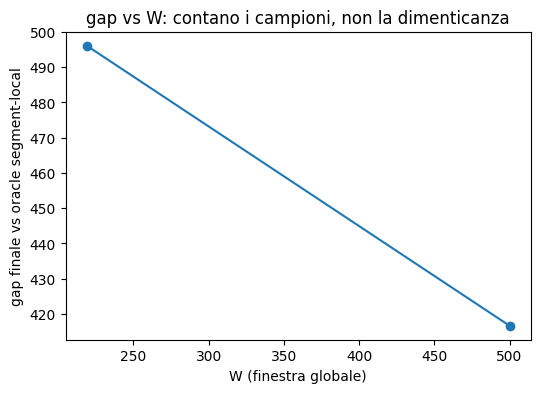

In [11]:
# Ablation: final mean gap of improved SW with the two windows.
# Thesis: widening the window reduces the gap -> in a mildly
# non-stationary environment, the limitation is samples per arm, not forgetting.
W_grid = [SW_WINDOW, SW_WINDOW_WIDE]        # 219 (formula del corso), 500 (L/2)
N_ABL = 30
ablation = []
for Wv in W_grid:
    gaps = []
    for j in range(N_ABL):
        env = PiecewiseStationaryEnv(seed=BASE_ENV_SEED + j)
        agent = SWCombUCBAgent(BASE_ENV_SEED + j + AGENT_SEED_OFFSETS['sw_ucb'], W=Wv)
        cum = 0.0
        for t in range(T):
            bids = agent.pull_arm()
            _, utilities, costs = env.round(bids)
            agent.update(utilities, costs)
            cum += utilities.sum()
        gaps.append(local_cum[-1] - cum)
    ablation.append((Wv, float(np.mean(gaps))))
    print(f'W={Wv:5d}  gap medio={np.mean(gaps):.1f}')

ws, gs = zip(*ablation)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ws, gs, 'o-')
ax.set_xlabel('W (finestra globale)')
ax.set_ylabel('gap finale vs oracle segment-local')
ax.set_title('gap vs W: samples matter, not forgetting')
plt.show()

## CUSUM diagnostics

mean resets per trial: 32.0 (2 change point x 27 arm = 54, riferimento: un reset per arm per change point)


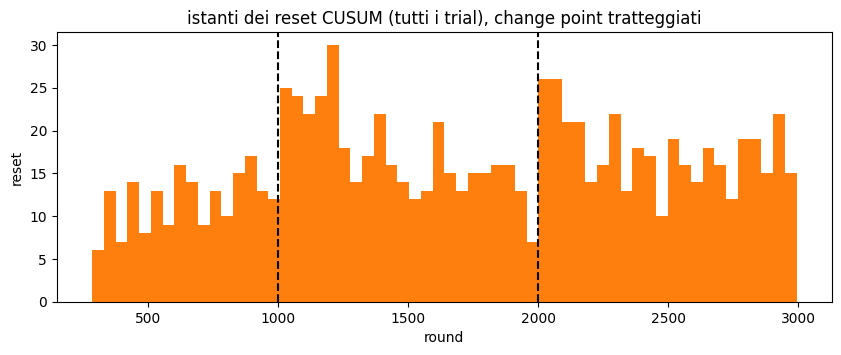

In [12]:
all_reset_times = [t for run in results['cusum_ucb'] for (t, i) in run['reset_times']]
mean_resets = np.mean([len(run['reset_times']) for run in results['cusum_ucb']])
n_positive_arms = int(PLAYABLE.sum())
print(f'mean resets per trial: {mean_resets:.1f} '
      f'({UPSILON_T} change point x {n_positive_arms} arm = {UPSILON_T * n_positive_arms}, riferimento: un reset per arm per change point)')

if all_reset_times:
    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.hist(all_reset_times, bins=60, color='tab:orange')
    for cp in CHANGE_POINTS:
        ax.axvline(cp, color='black', linestyle='--', linewidth=1.5)
    ax.set_title('CUSUM reset times (all trials), dashed change points')
    ax.set_xlabel('round')
    ax.set_ylabel('reset')
    plt.show()

## Plots

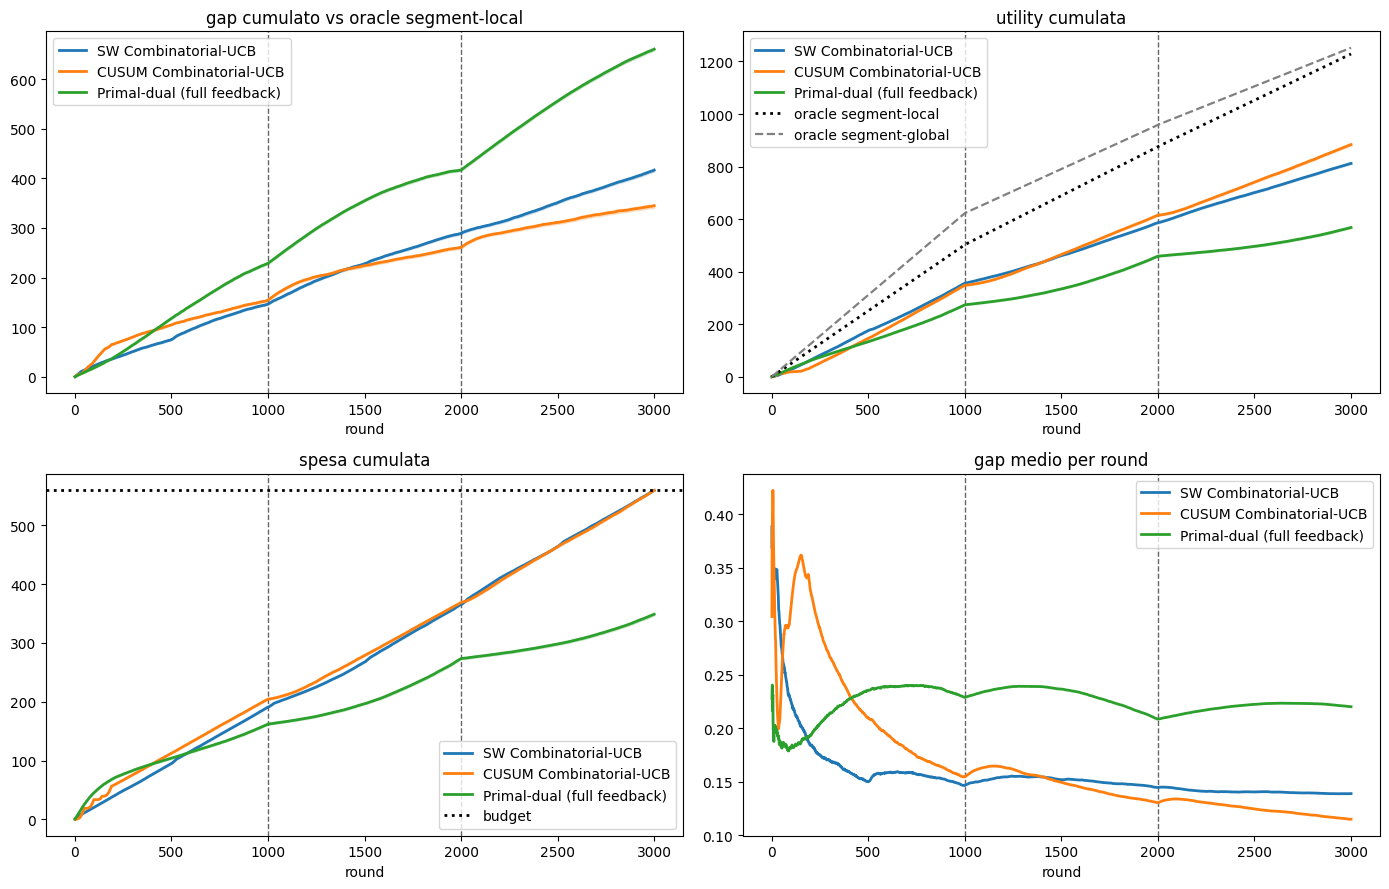

In [13]:
x = np.arange(1, T + 1)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax in axes.ravel():
    for cp in CHANGE_POINTS:
        ax.axvline(cp, color='black', linestyle='--', linewidth=1, alpha=0.6)

for name in AGENT_NAMES:
    m, sem = mean_sem(local_gap[name])
    axes[0, 0].plot(x, m, linewidth=2, color=COLORS[name], label=LABELS[name])
    axes[0, 0].fill_between(x, m - sem, m + sem, color=COLORS[name], alpha=0.18)
axes[0, 0].set_title('gap cumulato vs oracle segment-local')
axes[0, 0].set_xlabel('round')
axes[0, 0].legend()

for name in AGENT_NAMES:
    m, sem = mean_sem(utility[name])
    axes[0, 1].plot(x, m, linewidth=2, color=COLORS[name], label=LABELS[name])
    axes[0, 1].fill_between(x, m - sem, m + sem, color=COLORS[name], alpha=0.18)
axes[0, 1].plot(x, local_cum, color='black', linestyle=':', linewidth=2, label='oracle segment-local')
axes[0, 1].plot(x, global_cum, color='gray', linestyle='--', linewidth=1.6, label='oracle segment-global')
axes[0, 1].set_title('utility cumulata')
axes[0, 1].set_xlabel('round')
axes[0, 1].legend()

for name in AGENT_NAMES:
    m, sem = mean_sem(spend[name])
    axes[1, 0].plot(x, m, linewidth=2, color=COLORS[name], label=LABELS[name])
    axes[1, 0].fill_between(x, m - sem, m + sem, color=COLORS[name], alpha=0.18)
axes[1, 0].axhline(BUDGET, color='black', linestyle=':', linewidth=2, label='budget')
axes[1, 0].set_title('cumulative expenditure')
axes[1, 0].set_xlabel('round')
axes[1, 0].legend()

for name in AGENT_NAMES:
    m, _ = mean_sem(local_gap[name])
    axes[1, 1].plot(x, m / x, linewidth=2, color=COLORS[name], label=LABELS[name])
axes[1, 1].set_title('gap medio per round')
axes[1, 1].set_xlabel('round')
axes[1, 1].legend()

fig.tight_layout()
plt.show()

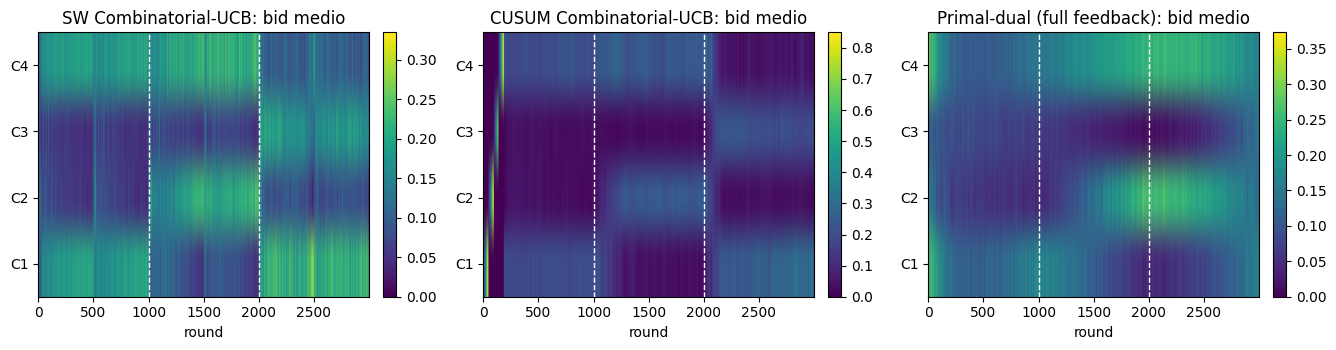

In [14]:
n_cols = len(AGENT_NAMES)
fig, axes = plt.subplots(1, n_cols, figsize=(4.5 * n_cols, 3.6))
for col, name in enumerate(AGENT_NAMES):
    mean_bid = np.stack([run['bids'] for run in results[name]]).mean(axis=0).T
    im = axes[col].imshow(mean_bid, aspect='auto', origin='lower', cmap='viridis')
    for cp in CHANGE_POINTS:
        axes[col].axvline(cp, color='white', linestyle='--', linewidth=1)
    axes[col].set_title(f'{LABELS[name]}: bid medio')
    axes[col].set_xlabel('round')
    axes[col].set_yticks(range(N_CAMPAIGNS))
    axes[col].set_yticklabels([f'C{i+1}' for i in range(N_CAMPAIGNS)])
    fig.colorbar(im, ax=axes[col], fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

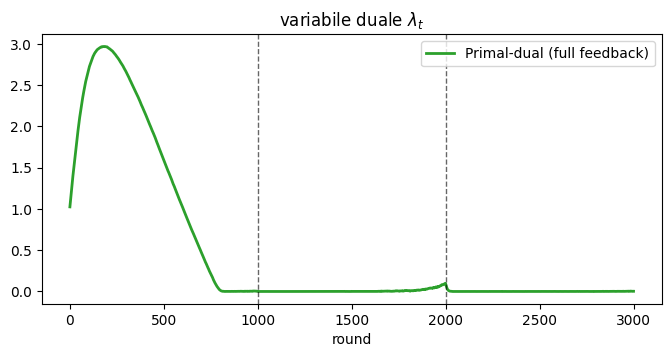

In [15]:
fig, ax = plt.subplots(figsize=(8, 3.5))
for name in AGENT_NAMES:
    if 'lambda' in results[name][0]:
        lam = np.vstack([run['lambda'] for run in results[name]]).mean(axis=0)
        ax.plot(np.arange(1, T + 1), lam, linewidth=2, color=COLORS[name], label=LABELS[name])
for cp in CHANGE_POINTS:
    ax.axvline(cp, color='black', linestyle='--', linewidth=1, alpha=0.6)
ax.set_title('variabile duale $\\lambda_t$')
ax.set_xlabel('round')
ax.legend()
plt.show()

## Final observations

Same environment and seeds as the baseline version. The gap to the segment-local benchmark decreases for the two UCB methods: SW from 562 to 417, CUSUM from 533 to 345 (mean gap per round 0.139 and 0.115). The three changes act on two distinct sides. Dynamic pacing and empirical cost fix budget management: they spread expenditure to the end of the horizon instead of exhausting it early. Window width (W = 500 rather than 219) fixes the sample side, giving more observations to each arm; CUSUM also benefits, with resets rising to about 32 per trial and concentrating near the true change points.

The gap-vs-W ablation confirms the thesis: moving from the course window (W = 219, gap 496) to the wider one (W = 500, gap 417) decreases the gap. If responsiveness—forgetting quickly to adapt—were the limitation, increasing W would worsen performance; instead it improves it, so in a mildly non-stationary environment the limitation is samples per arm, not forgetting.

On the primal-dual side, even the improved Requirement 3 version (theoretical learning rates) remains behind: gap 660 versus 716 with the lab constants (0.220 per round), with a substantial part of the budget unused (211 out of 560). The limitation is not the constants but the target: it retains the entire history and pursues the best fixed distribution in hindsight, which is the wrong target over three segments. The requested comparison is therefore clear: the two non-stationary UCB methods beat primal-dual on this instance (CUSUM-UCB slightly ahead of SW-UCB), always respecting the budget. A semi-windowed primal-dual variant was tested but not included; it still remains below the non-stationary UCB methods and is discussed in the README.